M505 - Intro to AI and Machine Learning

Rosemarie Exile

GH1054171

                                    FRAUD DETECTION USING LOGISTIC REGRESSION AND DECISION TREE


Introduction

Fraud is defined as "intentional deception to deprive a victim of a legal right or to gain from a victim unlawfully or unfairly." There are three different fraud categories: asset misappropriation, corruption, and financial fraud. This project will focus on analyzing financial fraud detection.

Fraud detection is a good example of the application of machine learning. Using machine learning to recognize patterns in input data, we can determine whether a transaction is possibly fraudulent or legitimate. This could help companies, especially in the financial industry, immediately respond to and remediate any financial losses and gain customers' trust with their strengthened security detection tool.

Problem Statement

This project aims to recognize possible fraudulent activities based on the features present in the dataset. This is a binary classification problem, as the outcome is either a fraudulent or legitimate transaction. We will apply machine learning to determine which scikit-learn classification model provides the best performance for fraud detection.


Data Collection

The data used in this project is from Kaggle with sample size of 51,000. The dataset is suitable for this project as it provides good quality of features we cacn consider in determining fraud and the sample size is big enough to use for this give us meaningful outcome. Website: https://www.kaggle.com/code/nikolasgegenava/fraud-detection-98-accuracy/input


In [84]:
#Import needed modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Read the dataset uploaded in GitHub
url = "https://raw.githubusercontent.com/bluefirerose/Machine-Learning/main/M505/Fraud%20Detection%20Dataset.csv"
df = pd.read_csv(url)

Dataset has been loaded from Github URL but originally from Kaggle. 

In [85]:
#Get 10 sample data from the end of dataset
df.tail(10)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50990,T12629,1157,2898.06,Online Purchase,8.0,Desktop,San Francisco,2,64,14,Credit Card,0
50991,T28348,1530,1069.09,ATM Withdrawal,6.0,Tablet,Houston,2,110,13,NaN,0
50992,T43512,1584,3631.26,Bank Transfer,17.0,Desktop,Seattle,4,81,13,Net Banking,0
50993,T5873,4911,3613.59,Online Purchase,11.0,Tablet,New York,3,58,7,Net Banking,0
50994,T48244,4842,1587.84,POS Payment,10.0,Tablet,New York,1,94,6,UPI,0
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


The table shows the last 10 data sample from the dataset. This gives us the a view of features and values within the csv file.  

Exploratory Data Analysis (EDA)

In [87]:
#Get the dataset total size
df.shape

(51000, 12)

This provide us the total sample size which is 51,000 and the column count which is 12 present in the dataset. 

In [88]:
#Get total range index, entries, columns, null count and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

Provide more details about the data we will be using.Each columns shows that total non-null count and the data type used. Here, we can identify the numerical and categorical variables. 

In [89]:
#Check missing data
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

Checking of NULL values for each freature. Missing data occured in Transaction_Amount, Time_of_Transaction, Device_Used, Location and Payment_Method. 

In [90]:
#View data with duplicate and show the total duplicate row
display(df.describe(include="all"))
print("Total duplicate rows:", df.duplicated().sum())

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000,51000.000000,48480.000000,51000,48448.000000,48527,48453,51000.000000,51000.000000,51000.000000,48531,51000.000000
unique,50000,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T21614,NaN,NaN,Bill Payment,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,10340,NaN,15795,6149,NaN,NaN,NaN,11887,NaN
mean,NaN,3005.110176,2996.249784,NaN,11.488400,NaN,NaN,1.995725,60.033902,7.495588,NaN,0.049216
std,NaN,1153.121107,5043.932555,NaN,6.922954,NaN,NaN,1.415150,34.384131,4.020080,NaN,0.216320
min,NaN,1000.000000,5.030000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2007.000000,1270.552500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2996.000000,2524.100000,NaN,12.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4006.000000,3787.240000,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


Total duplicate rows: 881


The table provides details of the data sample with duplicate values. Data is displayed in statistical summary for the numerical and categorical variables. There are 881 total duplicated rows we need to manage. 

In [91]:
#Shows total duplicate transaction IDs count
print("Total Duplicate Transaction IDs:",
      df.duplicated(subset=["Transaction_ID"]).sum())

# Shows some records with duplicate Transaction IDs
duplicate_transaction_ids = df[
    df.duplicated(subset=["Transaction_ID"], keep=False)
].sort_values(by="Transaction_ID")

# Display the table
display(duplicate_transaction_ids)

Total Duplicate Transaction IDs: 1000


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50688,T1004,4190,2828.74,Bill Payment,21.0,Tablet,Boston,2,97,14,Credit Card,0
1003,T1004,4190,2828.74,Bill Payment,21.0,Tablet,Boston,2,97,14,Credit Card,0
50440,T10075,3686,3700.47,ATM Withdrawal,7.0,Mobile,San Francisco,1,38,10,Net Banking,0
10074,T10075,3686,3700.47,ATM Withdrawal,7.0,Mobile,San Francisco,1,38,10,Net Banking,0
50952,T10076,2798,1775.37,Online Purchase,NaN,Desktop,Seattle,4,33,4,Credit Card,1
...,...,...,...,...,...,...,...,...,...,...,...,...
50742,T9958,2822,4707.49,ATM Withdrawal,13.0,Desktop,San Francisco,1,91,10,UPI,1
50967,T9961,2255,3930.24,Bank Transfer,0.0,Desktop,Miami,4,102,3,Credit Card,0
9960,T9961,2255,3930.24,Bank Transfer,0.0,Desktop,Miami,4,102,3,Credit Card,0
998,T999,1797,1491.62,POS Payment,NaN,Tablet,Miami,2,27,1,Credit Card,0


Data shows that there were 1,000 duplicate transaction IDs in the dataset. The transaction IDs were checked to determine if each transaction sample is unique. Here, we identify if duplicate transaction IDs have duplicate entries. We will not automatically delete the duplicated transaction IDs, as they may contain different transaction information. The exact duplicates will be deleted during data cleaning.

Data Cleaning

In [92]:
#Delete the exact duplicates
df = df.drop_duplicates().copy()

The exact duplicate has been deleted to the data sample we will be using. 

In [93]:
print("Total new dataset shape:", df.shape)
print("Total rows after removing duplicates:", len(df))
print("Remaining duplicate rows:", df.duplicated().sum())
df.isnull().sum()

Total new dataset shape: (50119, 12)
Total rows after removing duplicates: 50119
Remaining duplicate rows: 0


Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2476
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                         2437
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2428
Fraudulent                             0
dtype: int64

From the initial dataset shape, which is 51,000, the 881 duplicate samples found have been deducted. Therefore, the new dataset count is now 50,119. There are no remaining duplicate rows. Also, the data count for TRansaction_Amoount, Time_of_Transaction, Device_Used, Location and Payment_Method has been updated after the duplicate deletion has been implemented. 

In [94]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,50119.000000,47643.000000,47614.000000,50119.000000,50119.000000,50119.000000,50119.000000
mean,3004.733195,2999.104599,11.488575,1.996448,60.029071,7.495640,0.049223
std,1152.620471,5061.206189,6.921244,1.415492,34.392569,4.019806,0.216335
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1269.830000,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2997.000000,2523.580000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4005.000000,3785.090000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


Run df.describe again to check the updated statisctical summary after the duplicate deletion. 

,Fraudulent,Transaction Type,Count,Percentage (%)
0,0,Legitimate,47652,95.08
1,1,Fraudulent,2467,4.92


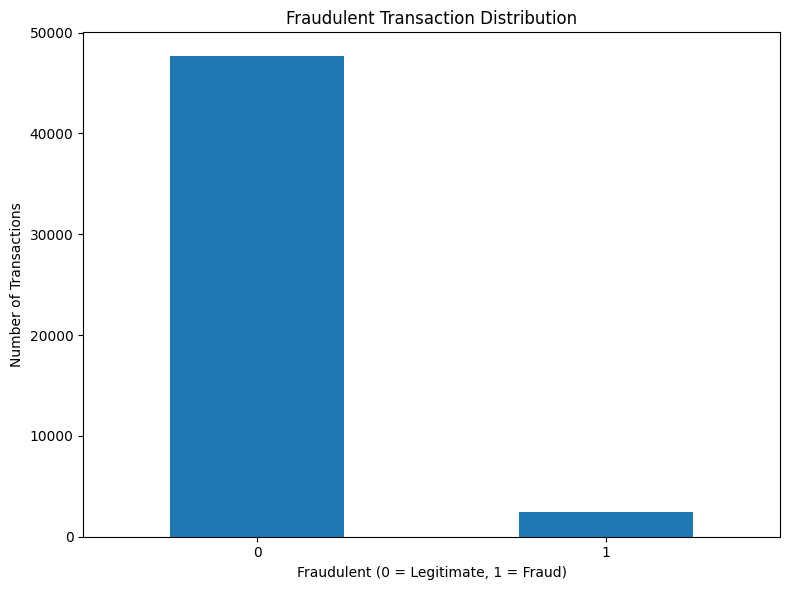

In [95]:
# Table for fraudulent count and percentage
fraud_count = df["Fraudulent"].value_counts().sort_index()
fraud_percentage = (
    df["Fraudulent"].value_counts(normalize=True).sort_index() * 100
)

fraud_table = pd.DataFrame({
    "Fraudulent": fraud_count.index,
    "Transaction Type": ["Legitimate", "Fraudulent"],
    "Count": fraud_count.values,
    "Percentage (%)": fraud_percentage.values
})

fraud_table["Percentage (%)"] = fraud_table["Percentage (%)"].round(2)

display(fraud_table)

# Create bar graph
df["Fraudulent"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Fraudulent Transaction Distribution")
plt.xlabel("Fraudulent (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Comparing the number of fraudulent transaction distributions, in the new data shape count, we have a total of 47,652 legitimate transactions, and that is 95.08 percent of the total count, while fraudulent transactions totaled 2,467, which makes up 4.92 percent of the new total data shape.

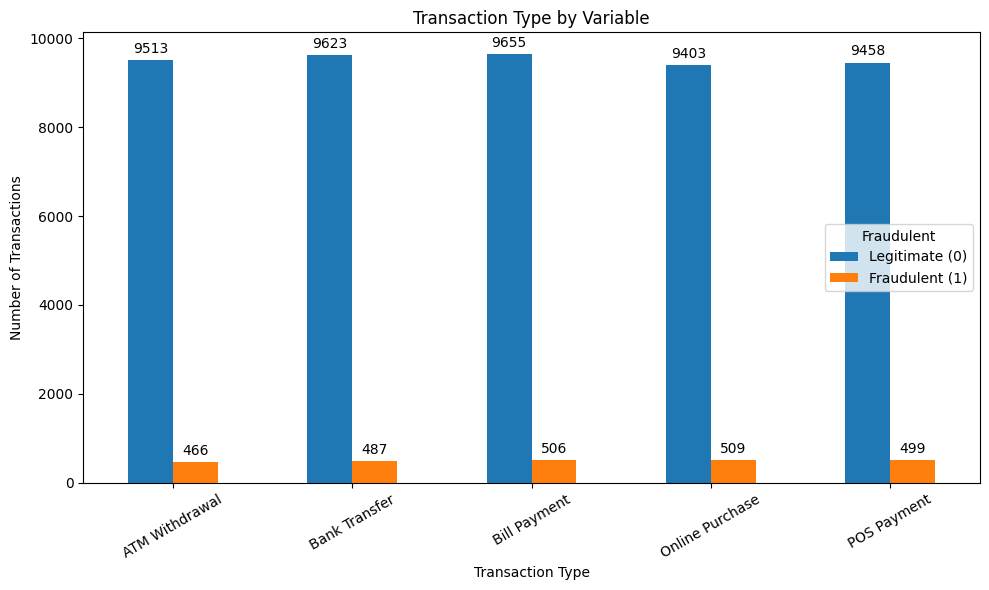

In [96]:
# Create transaction type count table
transaction_counts = pd.crosstab(
    df["Transaction_Type"],
    df["Fraudulent"]
)

# Create bar graph
ax = transaction_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add exact number above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.title("Transaction Type by Variable")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.legend(
    title="Fraudulent",
    labels=["Legitimate (0)", "Fraudulent (1)"]
)
plt.tight_layout()
plt.show()

Comparing the fraudulent and legitimate activities per transaction type, Online Purchase shows the highest fraudulent count. Checking the other types, the numbers are close to each other.

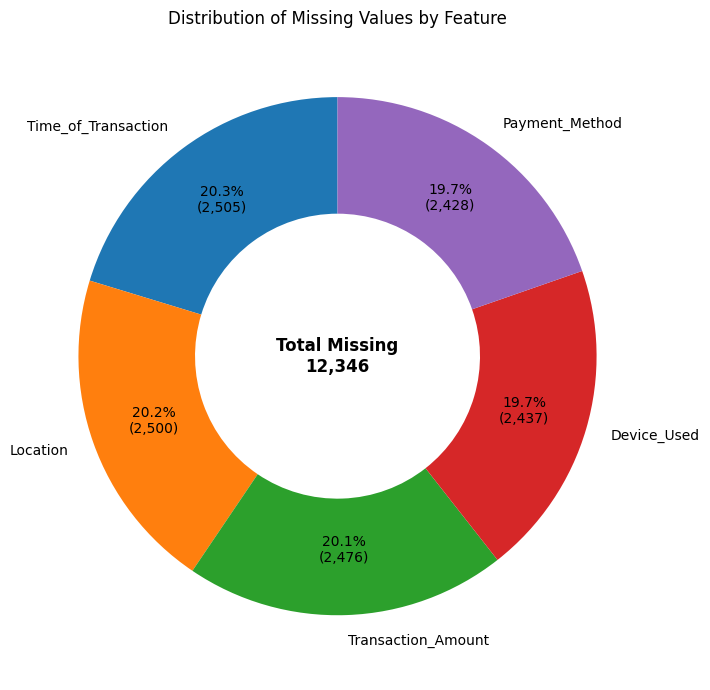

In [97]:
# Count missing values in each feature
missing_counts = df.isnull().sum()

# Keep only columns with missing values
missing_counts = missing_counts[
    missing_counts > 0
].sort_values(ascending=False)

# Total missing values across all features
total_missing = missing_counts.sum()

# Function to show percentage and count
def show_count_percentage(pct):
    count = int(round(pct / 100 * total_missing))
    return f"{pct:.1f}%\n({count:,})"

# Create donut chart
plt.figure(figsize=(9, 7))

plt.pie(
    missing_counts.values,
    labels=missing_counts.index,
    autopct=show_count_percentage,
    startangle=90,
    wedgeprops={"width": 0.45},
    pctdistance=0.75
)

# Add total missing values in the center
plt.text(
    0, 0,
    f"Total Missing\n{total_missing:,}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

plt.title("Distribution of Missing Values by Feature")
plt.tight_layout()
plt.show()

Identify the features with missing values. There's a total of 12,346 missing values for the features Time_of Transaction, Location, Transaction_Amount, Device_Used and Payment_Method. This needs to be identified during data processing. Median imputation will be applied to numerical values while SimpleImputer will be use for categorical values for machine learning pipeline. 

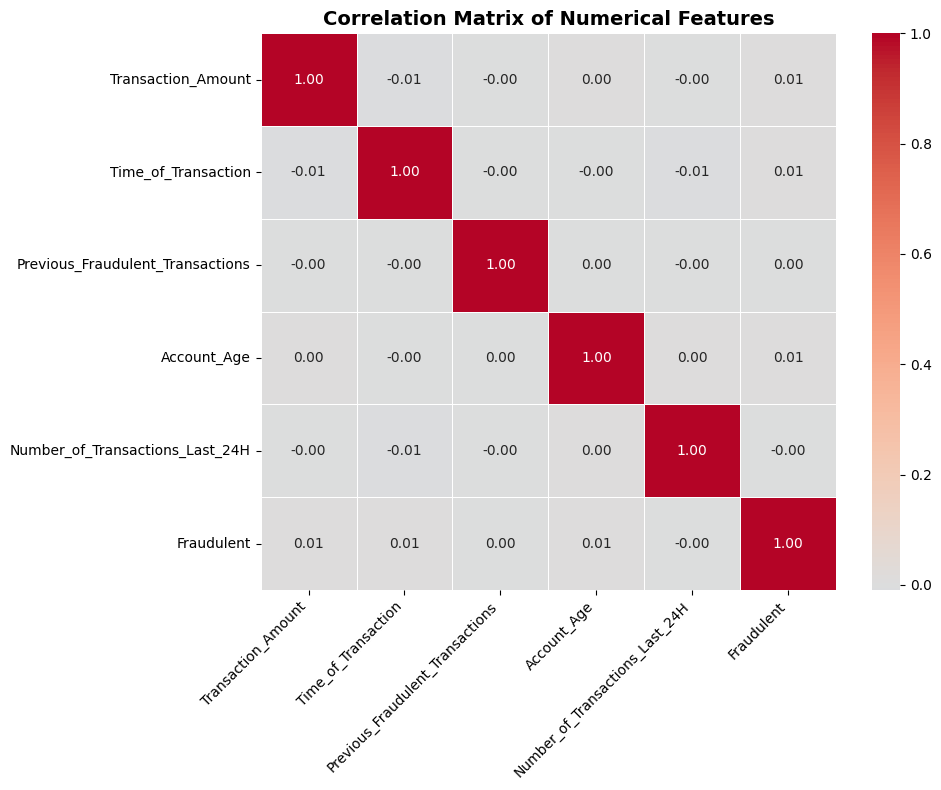

In [98]:
import seaborn as sns

# Select columns for correlation
correlation_columns = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
    "Fraudulent"
]

# Create correlation matrix 
correlation_matrix = df[correlation_columns].corr()

# Create heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The correlation matrix shows the relationship between the numerical features and the fraudulent value. It indicates a weak correlation, as the results show values close to zero. This does not mean the features cannot predict the outcome. Still, using a nonlinear pattern can be used to identify correlations, like the decision tree.

In [99]:
TARGET = "Fraudulent"

# Separate model features and target
# Transaction_ID and User_ID are identifiers, so they are excluded
X = df.drop(columns=[TARGET, "Transaction_ID", "User_ID"])
y = df[TARGET]

numeric_features = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]

categorical_features = [
    "Transaction_Type",
    "Device_Used",
    "Location",
    "Payment_Method"
]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (50119, 9)
Target shape: (50119,)


Transaction_ID and User_ID has been removed to the features as they are identifiers. Numeric and categorical feature is separated to prepare for data pre-processing. 

Data Cleaning

In [100]:
# Data cleaning result

print("1. Cleaned dataset shape:", df.shape)

print("\n2. Remaining duplicate rows:", df.duplicated().sum())

print("\n3. X shape:", X.shape)

print("\n4. y shape:", y.shape)

print("\n5. Features used for machine learning:", X.columns.tolist())

print("\n6. Target variable:", y.name)

print("\n7. Target class count:")
print(y.value_counts())

print("\n8. Target class percentage:")
print(y.value_counts(normalize=True) * 100)

print("\n9. Missing values remaining in X:")
print(X.isnull().sum())

1. Cleaned dataset shape: (50119, 12)

2. Remaining duplicate rows: 0

3. X shape: (50119, 9)

4. y shape: (50119,)

5. Features used for machine learning: ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method']

6. Target variable: Fraudulent

7. Target class count:
Fraudulent
0    47652
1     2467
Name: count, dtype: int64

8. Target class percentage:
Fraudulent
0    95.077715
1     4.922285
Name: proportion, dtype: float64

9. Missing values remaining in X:
Transaction_Amount                  2476
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                         2437
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2428
dtype: int64


Lisitng the data cleaning result, verifying the new dataset count, number of columns, remaining duplicate rows, target columns count, machine learning features, target variable and missing values remaining in the new data shape. Missing values will be handled during SimpleImputer processing. 

Preprocessing Comparison

In [101]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_pipeline_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_1, numeric_features),
    ("cat", categorical_pipeline_A, categorical_features)
])


In [115]:
# Apply Preprocessing Strategy A 
X_processed_A = preprocessor_A.fit_transform(X)

# Get the new feature names
feature_names_A = preprocessor_A.get_feature_names_out()

# Convert processed data into a DataFrame
X_processed_A_df = pd.DataFrame(
    X_processed_A,
    columns=feature_names_A
)

# Check results
print("Original X shape:", X.shape)
print("Processed X shape:", X_processed_A_df.shape)

print("\nMissing values BEFORE preprocessing:")
print(X.isnull().sum())

print("\nTotal missing values BEFORE preprocessing:")
print(X.isnull().sum().sum())

print("\nTotal missing values AFTER preprocessing:")
print(X_processed_A_df.isnull().sum().sum())

print("\nProcessed data:")
display(X_processed_A_df.head())

Original X shape: (50119, 9)
Processed X shape: (50119, 27)

Missing values BEFORE preprocessing:
Transaction_Amount                  2476
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                         2437
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2428
dtype: int64

Total missing values BEFORE preprocessing:
12346

Total missing values AFTER preprocessing:
0

Processed data:


,num__Transaction_Amount,num__Time_of_Transaction,num__Previous_Fraudulent_Transactions,num__Account_Age,num__Number_of_Transactions_Last_24H,cat__Transaction_Type_ATM Withdrawal,cat__Transaction_Type_Bank Transfer,cat__Transaction_Type_Bill Payment,cat__Transaction_Type_Online Purchase,cat__Transaction_Type_POS Payment,...,cat__Location_Los Angeles,cat__Location_Miami,cat__Location_New York,cat__Location_San Francisco,cat__Location_Seattle,cat__Payment_Method_Credit Card,cat__Payment_Method_Debit Card,cat__Payment_Method_Invalid Method,cat__Payment_Method_Net Banking,cat__Payment_Method_UPI
0,1292.76,16.0,0.0,119.0,13.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1554.58,13.0,4.0,79.0,3.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2395.02,12.0,3.0,115.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,100.10,15.0,4.0,3.0,4.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1490.50,19.0,2.0,57.0,7.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Strategy A imputation has been executed above, showing how missing numerical values are replaced using median imputation and missing categorical values are replaced using most-frequent imputation. One-hot encoding was also used to convert the categorical feature values into numerical values. The results were then combined to prepare the dataset for machine-learning training.

In [103]:
from sklearn.preprocessing import StandardScaler

numeric_pipeline_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_pipeline_B, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


In [116]:
# Apply Preprocessing Strategy B scaling
X_processed_B = preprocessor_B.fit_transform(X)

# Get feature names after preprocessing
feature_names_B = preprocessor_B.get_feature_names_out()

# Convert to DataFrame
X_processed_B_df = pd.DataFrame(
    X_processed_B,
    columns=feature_names_B
)

# Check the results
print("Original X shape:", X.shape)
print("Processed X shape:", X_processed_B_df.shape)

print("\nMissing values BEFORE preprocessing:")
print(X.isnull().sum().sum())

print("\nMissing values AFTER preprocessing:")
print(X_processed_B_df.isnull().sum().sum())

print("\nProcessed data:")
display(X_processed_B_df.head())

Original X shape: (50119, 9)
Processed X shape: (50119, 27)

Missing values BEFORE preprocessing:
12346

Missing values AFTER preprocessing:
0

Processed data:


,num__Transaction_Amount,num__Time_of_Transaction,num__Previous_Fraudulent_Transactions,num__Account_Age,num__Number_of_Transactions_Last_24H,cat__Transaction_Type_ATM Withdrawal,cat__Transaction_Type_Bank Transfer,cat__Transaction_Type_Bill Payment,cat__Transaction_Type_Online Purchase,cat__Transaction_Type_POS Payment,...,cat__Location_Los Angeles,cat__Location_Miami,cat__Location_New York,cat__Location_San Francisco,cat__Location_Seattle,cat__Payment_Method_Credit Card,cat__Payment_Method_Debit Card,cat__Payment_Method_Invalid Method,cat__Payment_Method_Net Banking,cat__Payment_Method_UPI
0,-0.340960,0.664877,-1.410441,1.714659,1.369323,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.287913,0.220229,1.415459,0.551605,-1.118384,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.117633,0.072013,0.708984,1.598353,0.374241,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.582603,0.516661,1.415459,-1.658197,-0.869613,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.300896,1.109525,0.002509,-0.088074,-0.123301,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Strategy B imputation has been executed above, showing how missing numerical values are replaced using median imputation and then standardized using StandardScaler. Missing categorical values are replaced using most-frequent imputation. One-hot encoding was also used to convert the categorical feature values into numerical values. The results were then combined to prepare the dataset for machine-learning training.

In [117]:
comparison = pd.DataFrame({
    "Original Transaction Amount": X["Transaction_Amount"].head(10),
    "Strategy A - Not Scaled":
        X_processed_A_df["num__Transaction_Amount"].head(10),
    "Strategy B - StandardScaler":
        X_processed_B_df["num__Transaction_Amount"].head(10)
})

display(comparison)

,Original Transaction Amount,Strategy A - Not Scaled,Strategy B - StandardScaler
0,1292.76,1292.76,-0.340960
1,1554.58,1554.58,-0.287913
2,2395.02,2395.02,-0.117633
3,100.10,100.10,-0.582603
4,1490.50,1490.50,-0.300896
5,2372.04,2372.04,-0.122289
6,544.81,544.81,-0.492501
7,635.75,635.75,-0.474076
8,2318.87,2318.87,-0.133062
9,3656.17,3656.17,0.137887


The table shows a comparison of the values after Strategy A and Strategy B – StandardScaler have been executed. The values in Strategy A have not been changed, as no scaling has been executed, while Strategy B transforms the transaction amounts based on the mean and standard deviation. A negative value indicates that the transaction amount is below the mean, a positive value indicates that it is above the mean, and a value close to 0 indicates that the transaction amount is close to the mean.

Train, Test and Split Data

In [118]:
# Create train/test summary table
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],

    "Number of Transactions": [
        len(X_train),
        len(X_test)
    ],

    "Dataset Percentage": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100
    ],

    "Legitimate (0)": [
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],

    "Legitimate (%)": [
        (y_train == 0).mean() * 100,
        (y_test == 0).mean() * 100
    ],

    "Fraudulent (1)": [
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],

    "Fraudulent (%)": [
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ]
})

# Round percentages
split_summary[
    ["Dataset Percentage", "Legitimate (%)", "Fraudulent (%)"]
] = split_summary[
    ["Dataset Percentage", "Legitimate (%)", "Fraudulent (%)"]
].round(2)

display(split_summary)

,Dataset,Number of Transactions,Dataset Percentage,Legitimate (0),Legitimate (%),Fraudulent (1),Fraudulent (%)
0,Training,40095,80.0,38121,95.08,1974,4.92
1,Testing,10024,20.0,9531,95.08,493,4.92


Training data will use 80%, while testing data will use 20%. The data will be processed with 40,095 transactions for training and 10,024 transactions for testing.

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Transaction_Amount',
                                                   'Time_of_Transaction',
                                                   'Previous_Fraudulent_Transactions',
                                                   'Account_Age',
                                                   'Number_of_Transactions_Last_24H']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Transaction_Type',
                                                   'Device_Used', 'Location',
                                                   'Payment_Method'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [120]:
# Display Logistic Regression pipeline
logistic_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Transaction_Amount',
                                                   'Time_of_Transaction',
                                                   'Previous_Fraudulent_Transactions',
                                                   'Account_Age',
                                                   'Number_of_Transactions_Last_24H']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Transaction_Type',
                                                   'Device_Used', 'Location',
                                                   'Payment_Method'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

Pipelines are created for Logistic Regression and Decision Tree. 

In [121]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }

baseline_results = pd.DataFrame([
    evaluate_model("Logistic Regression", logistic_model, X_test, y_test),
    evaluate_model("Decision Tree", decision_tree_model, X_test, y_test)
])

display(baseline_results.round(4))


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9508,0.0000,0.0000,0.0000,0.4878
1,Decision Tree,0.8894,0.0375,0.0507,0.0431,0.4917


Comparing the Logistic Regression and Decision Tree models for accuracy, precision, recall, F1-score, and ROC-AUC (Receiver Operating Characteristic – Area Under the Curve), Logistic Regression got 95.08% accuracy but 0% recall, which means it did not detect any fraudulent transactions. Meanwhile, the Decision Tree got 88.94% accuracy and detected 5.07% recall. This is a low result, but it is still a good sign that the model was able to detect some fraudulent transactions.

In [124]:
# Strategy A: Imputation + One-Hot Encoding

logistic_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

# Train
logistic_A.fit(X_train, y_train)

# Predict
pred_A = logistic_A.predict(X_test)
score_A = logistic_A.predict_proba(X_test)[:, 1]

# Results
results_A = {
    "Strategy": "Strategy A: Impute + Encode",
    "Accuracy": accuracy_score(y_test, pred_A),
    "Precision": precision_score(y_test, pred_A, zero_division=0),
    "Recall": recall_score(y_test, pred_A, zero_division=0),
    "F1-score": f1_score(y_test, pred_A, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, score_A)
}

pd.DataFrame([results_A]).round(4)

,Strategy,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Strategy A: Impute + Encode,0.9508,0.0,0.0,0.0,0.4875


In [125]:
# Strategy B: Imputation + One-Hot Encoding + StandardScaler

logistic_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

# Train
logistic_B.fit(X_train, y_train)

# Predict
pred_B = logistic_B.predict(X_test)
score_B = logistic_B.predict_proba(X_test)[:, 1]

# Results
results_B = {
    "Strategy": "Strategy B: Impute + Encode + Scale",
    "Accuracy": accuracy_score(y_test, pred_B),
    "Precision": precision_score(y_test, pred_B, zero_division=0),
    "Recall": recall_score(y_test, pred_B, zero_division=0),
    "F1-score": f1_score(y_test, pred_B, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, score_B)
}

pd.DataFrame([results_B]).round(4)

,Strategy,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Strategy B: Impute + Encode + Scale,0.9508,0.0,0.0,0.0,0.4878


In [126]:
# Compare both preprocessing strategies

strategy_comparison = pd.DataFrame([
    results_A,
    results_B
])

display(strategy_comparison.round(4))

,Strategy,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Strategy A: Impute + Encode,0.9508,0.0,0.0,0.0,0.4875
1,Strategy B: Impute + Encode + Scale,0.9508,0.0,0.0,0.0,0.4878


Both preprocessing strategies show almost similar performance. Strategy A and Strategy B show the same result for accuracy, with 0.9508, while precision, recall, and F1-score are 0. There is a slight difference in ROC-AUC. Still, the difference remains within weak classification performance.

MANUAL COMPUTATION
------------------
Accuracy = 0.9508
Precision = 0.0000
Recall = 0.0000
F1-score = 0.0000

CONFUSION MATRIX VALUES
-----------------------
True Negative (TN): 9531
False Positive (FP): 0
False Negative (FN): 493
True Positive (TP): 0


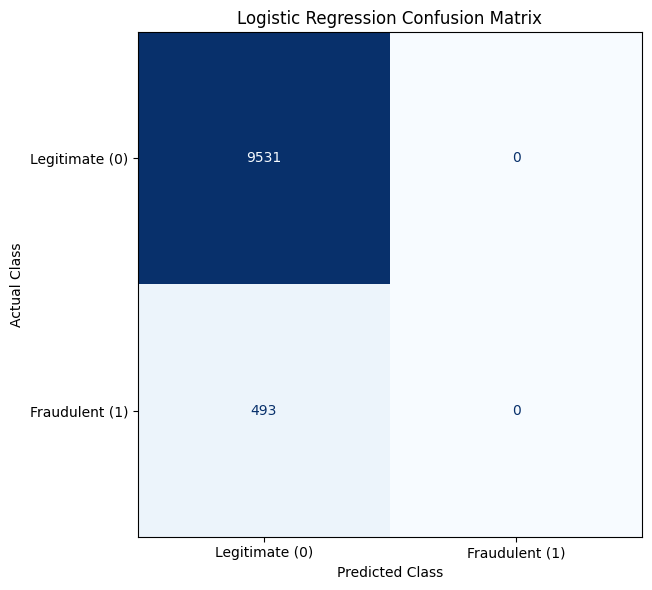

In [130]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions from Strategy B Logistic Regression
pred_B = logistic_B.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, pred_B)

# Get individual values FIRST
tn, fp, fn, tp = cm.ravel()

# Manual calculations
accuracy = (tp + tn) / (tp + tn + fp + fn)

precision = (
    tp / (tp + fp)
    if (tp + fp) > 0 else 0
)

recall = (
    tp / (tp + fn)
    if (tp + fn) > 0 else 0
)

f1 = (
    2 * (precision * recall) / (precision + recall)
    if (precision + recall) > 0 else 0
)

# Print results
print("MANUAL COMPUTATION")
print("------------------")
print(f"Accuracy = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall = {recall:.4f}")
print(f"F1-score = {f1:.4f}")

print("\nCONFUSION MATRIX VALUES")
print("-----------------------")
print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate (0)", "Fraudulent (1)"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

Confusion matrix guides us that there are 9,531 legitimate transaction found and 493 fraudulent transaction. 

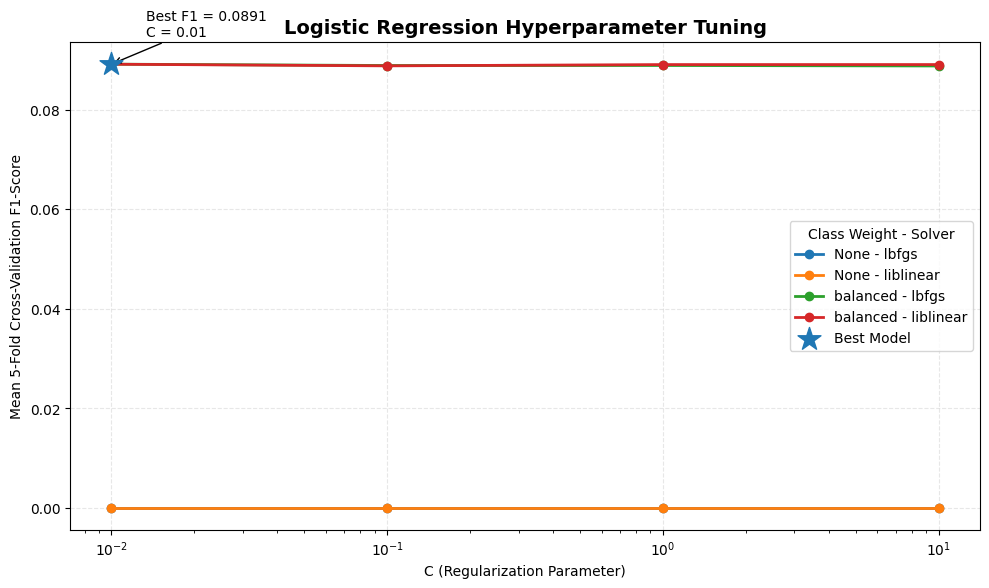

In [148]:

# Get GridSearchCV results
results = pd.DataFrame(logistic_search.cv_results_)

# Convert C to numeric
results["C"] = pd.to_numeric(results["param_model__C"])

# Create readable class-weight labels
results["Class Weight"] = (
    results["param_model__class_weight"]
    .astype(str)
)

# Create figure
plt.figure(figsize=(10, 6))

# Plot each class weight and solver combination
for (weight, solver), group in results.groupby(
    ["Class Weight", "param_model__solver"]
):
    
    group = group.sort_values("C")
    
    plt.plot(
        group["C"],
        group["mean_test_score"],
        marker="o",
        linewidth=2,
        label=f"{weight} - {solver}"
    )

# Highlight the best model
best_c = logistic_search.best_params_["model__C"]
best_f1 = logistic_search.best_score_

plt.scatter(
    best_c,
    best_f1,
    marker="*",
    s=300,
    zorder=5,
    label="Best Model"
)

# Label the best result
plt.annotate(
    f"Best F1 = {best_f1:.4f}\n"
    f"C = {best_c}",
    xy=(best_c, best_f1),
    xytext=(25, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    fontsize=10
)

# Log scale because C values are 0.01, 0.1, 1, 10
plt.xscale("log")

plt.title(
    "Logistic Regression Hyperparameter Tuning",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Mean 5-Fold Cross-Validation F1-Score")

plt.legend(
    title="Class Weight - Solver"
)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()
plt.show()

Executed hyperparameter tuning for Logistic Regression to find better settings for how the model learns and behaves. Based on the graph, the best cross-validation F1-score is 0.0891, but this still indicates a low capability to detect fraudulent transactions.

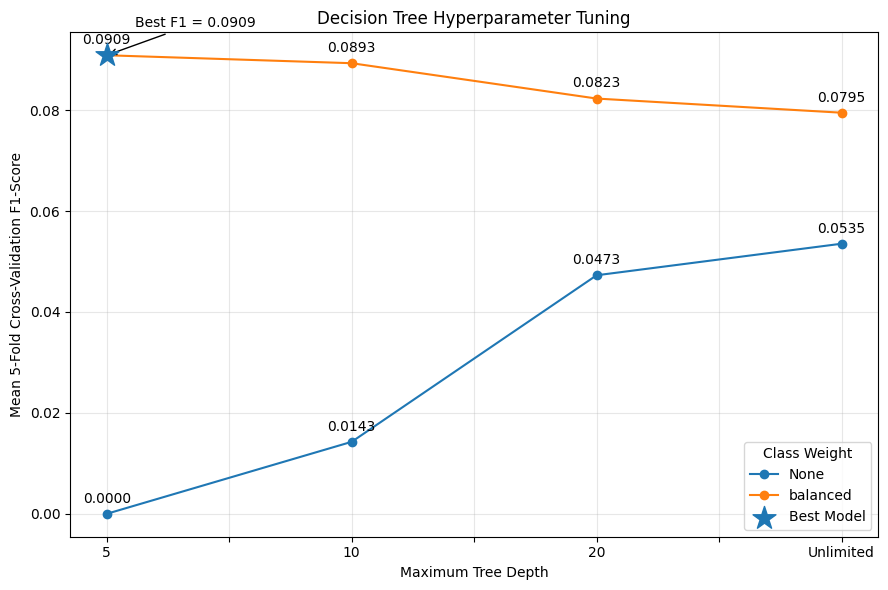

In [147]:
# Get GridSearchCV results
tree_results = pd.DataFrame(tree_search.cv_results_)

# Make max_depth readable
tree_results["Max Depth"] = (
    tree_results["param_model__max_depth"]
    .astype(str)
    .replace("None", "Unlimited")
)

# Make class weight readable
tree_results["Class Weight"] = (
    tree_results["param_model__class_weight"]
    .astype(str)
)

# Get the BEST F1-score for each
# max_depth + class_weight combination
tree_plot = (
    tree_results
    .groupby(
        ["Max Depth", "Class Weight"]
    )["mean_test_score"]
    .max()
    .unstack()
)

# Put depth values in logical order
depth_order = ["5", "10", "20", "Unlimited"]

tree_plot = tree_plot.reindex(
    [d for d in depth_order if d in tree_plot.index]
)

# Create graph
ax = tree_plot.plot(
    kind="line",
    marker="o",
    figsize=(9, 6)
)

# Add F1-score labels
for line in ax.lines:
    for x, y in zip(
        line.get_xdata(),
        line.get_ydata()
    ):
        ax.annotate(
            f"{y:.4f}",
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

# Highlight best overall Decision Tree result
best_f1 = tree_search.best_score_
best_depth = tree_search.best_params_["model__max_depth"]

best_depth_label = (
    "Unlimited"
    if best_depth is None
    else str(best_depth)
)

if best_depth_label in tree_plot.index:

    x_position = list(
        tree_plot.index
    ).index(best_depth_label)

    plt.scatter(
        x_position,
        best_f1,
        marker="*",
        s=300,
        zorder=5,
        label="Best Model"
    )

    plt.annotate(
        f"Best F1 = {best_f1:.4f}",
        (x_position, best_f1),
        xytext=(20, 20),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->"}
    )

plt.title(
    "Decision Tree Hyperparameter Tuning"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel(
    "Mean 5-Fold Cross-Validation F1-Score"
)

plt.legend(
    title="Class Weight"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Hyperparameter tuning was executed for the Decision Tree to find the best model settings. Based on the graph, the best cross-validation F1-score is 0.0909 at a maximum tree depth of 5 with balanced class weighting. The F1-score decreases as the balanced Decision Tree becomes deeper, indicating that the shallower tree performed better. However, the best F1-score of 0.0909 is still low, indicating a low capability to detect fraudulent transactions.

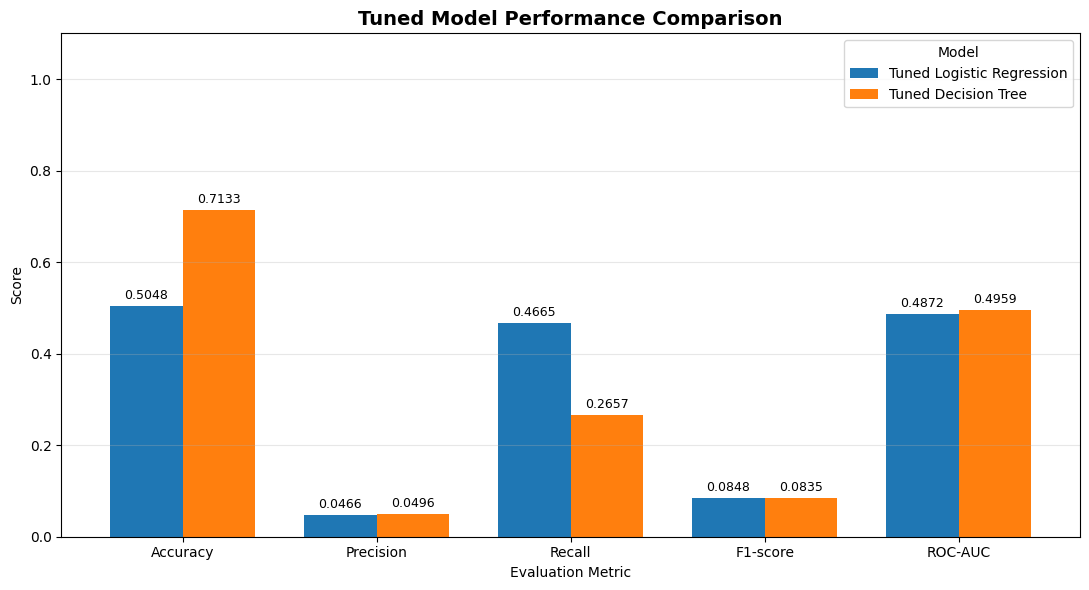

In [140]:
# Prepare data
plot_data = final_results_df.set_index("Model").T

# Create grouped bar chart
ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

# Add exact scores above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3,
        fontsize=9
    )

plt.title(
    "Tuned Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1.1)

plt.xticks(rotation=0)

plt.legend(
    title="Model"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Comparing the Tuned Logistic Regression and Tuned Decision Tree, the results show that the Tuned Decision Tree has higher accuracy, precision, and ROC-AUC, while the Tuned Logistic Regression shows higher recall and F1-score. The ROC-AUC scores are below 0.5, which indicates a weak overall ability to distinguish between fraudulent and legitimate transactions.

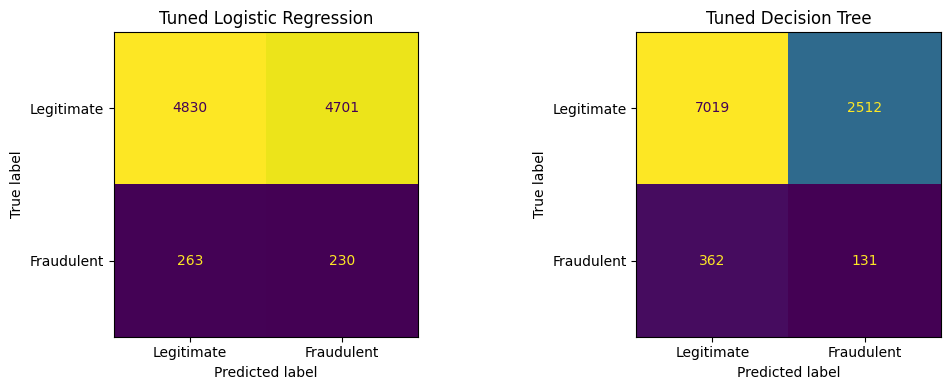

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, model) in zip(
    axes,
    [("Tuned Logistic Regression", best_logistic),
     ("Tuned Decision Tree", best_tree)]
):
    pred = final_predictions[name]
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Fraudulent"]
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


The confusion matrix shows the number of correct and incorrect predictions. In the graph above, true negatives show the highest number, while true positives show the lowest number. 

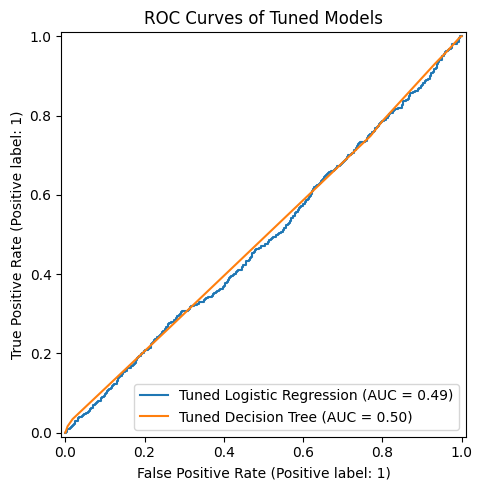

In [142]:
fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    final_scores["Tuned Logistic Regression"],
    name="Tuned Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    final_scores["Tuned Decision Tree"],
    name="Tuned Decision Tree",
    ax=ax
)

plt.title("ROC Curves of Tuned Models")
plt.tight_layout()
plt.show()


The ROC Curves compares the tuned logistic regression and tuned decision tree. Tuned decision tree has a better result but still considered as weak capanility to detect fraudulent activities. 

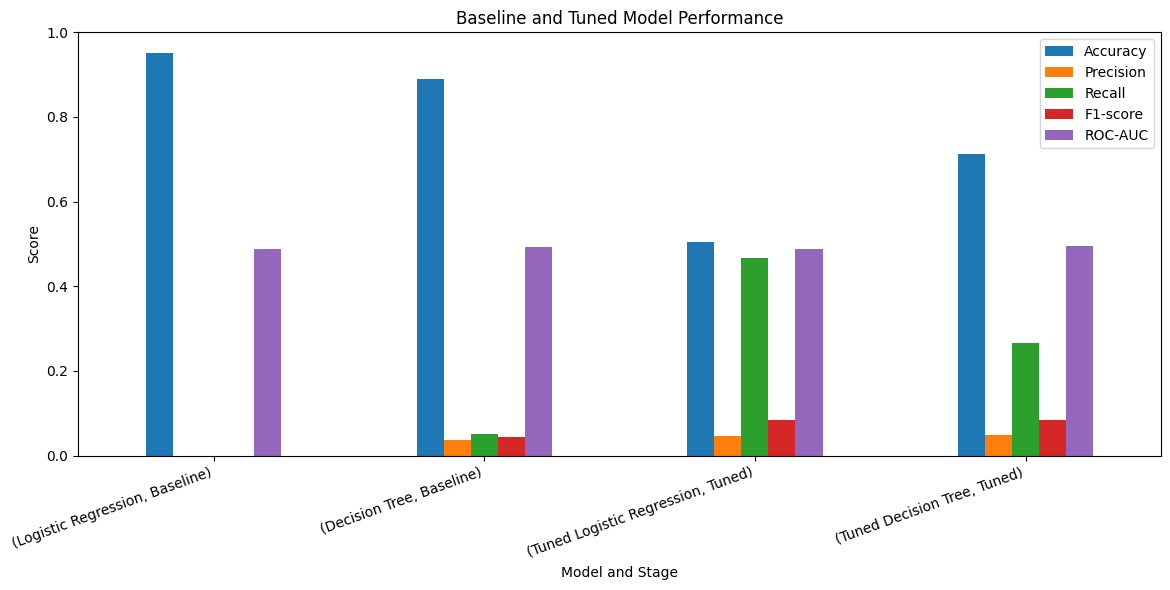

In [143]:
comparison_df = pd.concat([
    baseline_results.assign(Stage="Baseline"),
    final_results_df.assign(Stage="Tuned")
], ignore_index=True)

plot_df = comparison_df.set_index(["Model", "Stage"])[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Baseline and Tuned Model Performance")
plt.xlabel("Model and Stage")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Comparing the baseline results with the tuned results, precision, recall, and F1-score improved after hyperparameter tuning. However, accuracy decreased from the baseline to the tuned results, while ROC-AUC remained close to 0.50.

,Training Samples,Training F1,Validation F1
0,6415,0.1354,0.0916
1,12830,0.1109,0.0902
2,19245,0.1123,0.0910
3,25660,0.1054,0.0922
4,32076,0.1058,0.0909


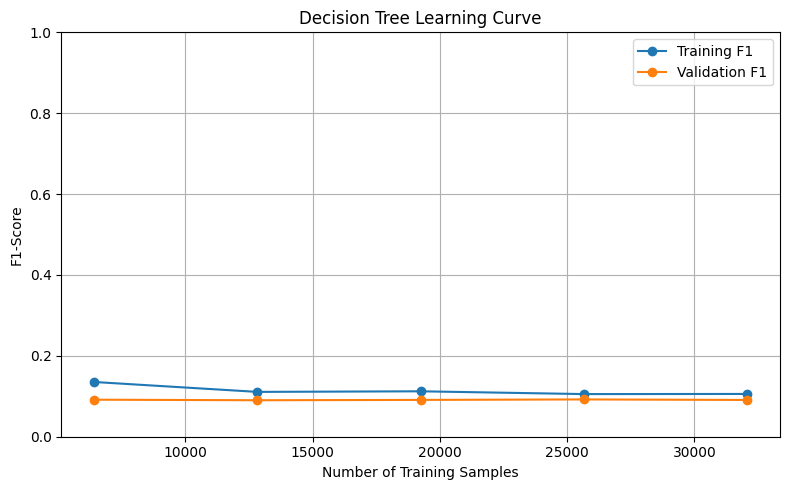

In [151]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_tree,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

# Create a table for the learning curve results
learning_curve_table = pd.DataFrame({
    "Training Samples": train_sizes,
    "Training F1": train_scores.mean(axis=1),
    "Validation F1": val_scores.mean(axis=1)
})

# Round F1-scores to 4 decimal places
learning_curve_table[
    ["Training F1", "Validation F1"]
] = learning_curve_table[
    ["Training F1", "Validation F1"]
].round(4)

display(learning_curve_table)



train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.title("Decision Tree Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


The Decision Tree learning curve shows low F1-scores for both training and validation. As the number of training samples increases, the training and validation F1-scores become closer. The Decision Tree has limited ability to learn patterns that distinguish fraudulent from legitimate transactions.

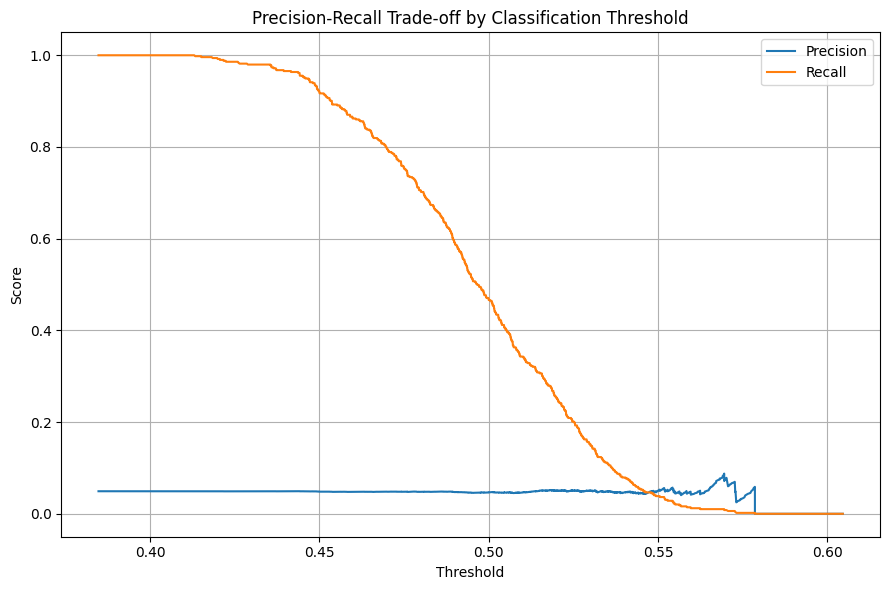

In [154]:
from sklearn.metrics import precision_recall_curve

# Illustration using the tuned Logistic Regression test scores for visualization.
scores = final_scores["Tuned Logistic Regression"]
precision, recall, thresholds = precision_recall_curve(y_test, scores)

plt.figure(figsize=(9, 6))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.title("Precision-Recall Trade-off by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Precision-Recall trade off graph shows that the higher the threshold the recall score drops to 0 while the precision stays low with relatively small changes.


Conclusion

This machine learning project evaluated a dataset containing 51,000 records to classify fraudulent and legitimate financial transactions. The dataset used was obtained from Kaggle and was examined using exploratory data analysis. It contained missing/null values and duplicate records. We cleaned the data by dropping duplicate records. 881 duplicate rows were removed which gives 50,119 clean data. For missing values, we used median imputation for numerical features and most-frequent imputation for categorical features. We used One-Hot Encoding for categorical features and StandardScaler for numerical features.

We separated the numerical and categorical features and executed a preprocessing comparison for Decision Tree and Logistic Regression. Missing values were handled through imputation, while StandardScaler was used to standardize the numerical features in Strategy B. We then split the data into 80% for training and 20% for testing. Using the data, we performed baseline model training and evaluated the accuracy, precision, recall, F1-score, and ROC-AUC for both Decision Tree and Logistic Regression. Hyperparameter tuning was then executed to find better model settings.

Baseline and tuning result for Decision tree shows higher in accuracy and precision while Logistic Regression shows higer result in F1-score. Though there's a significant change after tuning the data the f1-score shows weak result to distinguish fraudulent to legitiate transaction. 


Limitation

The dataset was found to be highly imbalanced, with approximately 95.08% legitimate transactions and 4.92% fraudulent transactions. Based on the baseline and tuned evaluations, the machine learning models require further improvement. More informative features or more representative data could be collected to improve the models' ability to distinguish fraudulent from legitimate transactions. The results show weak overall classification performance using Logistic Regression and Decision Tree, recommend to try explore other machine learning model for further analysis.
